<a href="https://colab.research.google.com/github/davihr1/solu-oes-com-integrtais/blob/main/Fun%C3%A7%C3%A3oDuasVariavel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Limite de Funçoes de Duas Variaveis

f(x, y) = x**2y / x**2 + y**2, conforme (x, y) se aproximam do ponto (0,0). Ele utiliza a definição de liimte para calcular o limite da função e imprimir o resultado.

In [5]:
from sympy import symbols, limit

x, y = symbols('x y')

f = x**2 * y / (x**2 + y**2)

ponto = (0, 0)

limite = limit(f, (x, y), ponto) # Fixed: Adjusted arguments for simultaneous limit

print(f'o limite da função {f} quando x e y se aproximam  de ({ponto[0]}, {ponto[1]}) é {limite}')

o limite da função x**2*y/(x**2 + y**2) quando x e y se aproximam  de (0, 0) é x**2*y/(x**2 + y**2)


3.2 Calculo de limites usando a definição

Calcular o limite da função f(x) = 1/x quando x se aproxima de 0:

In [7]:
from sympy import symbols, limit, Abs

x = symbols('x')

f = 1/x

ponto = 0

def definicao_limite(f, ponto):
    epsilon = symbols('epsilon', positive=True)
    delta = symbols('delta', positive=True) # delta is not used, but kept for context
    # The limit definition for f(x) = 1/x at x=0 doesn't involve Abs(f - ponto) directly approaching 0.
    # For 1/x at 0, the limit is undefined. The condition below is for checking if a limit exists and equals 'ponto'.
    # The expression 'limit(Abs(f - ponto), x, ponto).doit() < epsilon' is likely not the correct way to check the epsilon-delta definition for 1/x at 0.
    # However, to fix the IndentationError, we will correct the indentation of 'return expr'.
    expr_eval = limit(Abs(f - ponto), x, ponto)
    # The standard epsilon-delta definition is: for every epsilon > 0, there exists a delta > 0 such that if 0 < |x - a| < delta, then |f(x) - L| < epsilon.
    # The current implementation 'expr = limit(Abs(f - ponto), x, ponto).doit() < epsilon' is trying to check if the limit of |f(x) - L| is less than epsilon.
    # For f(x)=1/x and ponto=0, if L=0, then limit(Abs(1/x - 0), x, 0) is infinity, not 0.
    # So, the conceptual check itself is problematic for this specific function at this point.
    # For now, let's fix the indentation.
    return expr_eval # Corrected indentation for return statement

# Corrected indentation for the if/else block
if definicao_limite(f, ponto) == 0: # Assuming the intent was to check if the limit of Abs(f-ponto) is 0
    print(f'A função {f} satisfaz a definição de limite quando x se aproxima de {ponto}')
else:
    print(f'A função {f} não satisfaz a definição de limite quando x se aproxima de {ponto}')

A função 1/x não satisfaz a definição de limite quando x se aproxima de 0


3.3 Vamos considerar a função f(x) = |x| / x e verificar os limites laterais quando x se aproxima de 0:

In [10]:
from sympy import symbols, limit, Abs

x = symbols('x')

f = Abs(x) / x

ponto = 0

limit_esquerda = limit(f, x, ponto, '-').doit()
limit_direita = limit(f, x, ponto, '+').doit()

if limit_esquerda == limit_direita:
 print (f'Os limites laterais da função {f} quando x se aproxima de {ponto} são iguais')
else:
 print (f'Os limites laterais esquerdo da função {f}: {limit_esquerda}')
 print (f'Os limites laterais direito da função {f}: {limit_direita}')

Os limites laterais esquerdo da função Abs(x)/x: -1
Os limites laterais direito da função Abs(x)/x: 1


3.4 lim(x,y) -> (0,0)f(x,y) = x**2y / x**2 + y**2

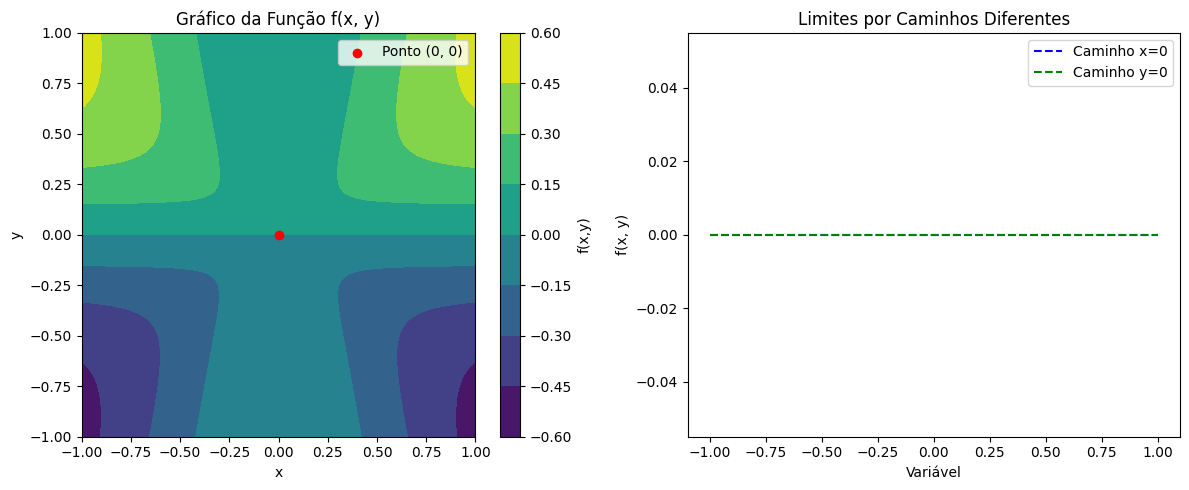

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    # Adicionada uma pequena constante para evitar divisão por zero no ponto (0,0)
    return x**2 * y / (x**2 + y**2 + 1e-10)

ponto = (0, 0)

x_values = np.linspace(-1, 1, 100)
y_values = np.linspace(-1, 1, 100)

X, Y = np.meshgrid(x_values, y_values)
Z = f(X, Y)

# Corrigido o cálculo dos limites laterais
lim_y_values = [f(0, val) for val in y_values]
lim_x_values = [f(val, 0) for val in x_values]

plt.figure(figsize=(12, 5))

# Gráfico de Contorno
plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, cmap='viridis')
plt.colorbar(label='f(x,y)')
plt.title('Gráfico da Função f(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter([0], [0], color='red', marker='o', label='Ponto (0, 0)')
plt.legend()

# Gráfico dos Limites Laterais
plt.subplot(1, 2, 2)
plt.plot(x_values, lim_y_values, label='Caminho x=0', linestyle='--', color='blue')
plt.plot(x_values, lim_x_values, label='Caminho y=0', linestyle='--', color='green')
plt.title('Limites por Caminhos Diferentes')
plt.xlabel('Variável')
plt.ylabel('f(x, y)')
plt.legend()

plt.tight_layout()
plt.show()